In [ ]:
import os

file_name = 'archive (2).zip'

if os.path.exists(file_name):
    size = os.path.getsize(file_name)
    print(f"File found! Size: {size / (1024*1024):.2f} MB")
else:
    print("File NOT found. Please check the upload sidebar.")

File found! Size: 407.21 MB


In [ ]:
import zipfile

# Exact filename from your upload
zip_file_name = '/content/archive (2).zip'

# This unpacks the photos into a folder called 'project_data'
try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('project_data')
    print("Success! Your photos are unzipped and ready.")
except Exception as e:
    print(f"Error: {e}")

Success! Your photos are unzipped and ready.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Data Preprocessing
image_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Load Dataset (Updated to your project_data folder)
train_generator = datagen.flow_from_directory(
    'project_data', # The folder you unzipped earlier
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    'project_data',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 25200 images belonging to 1 classes.
Found 6300 images belonging to 1 classes.


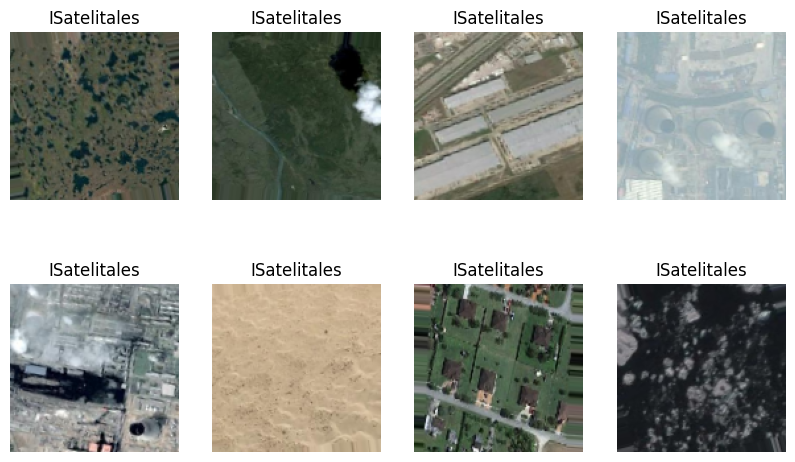

In [ ]:
# Visualize Data
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

In [ ]:
# MLP Model (Baseline) for 45 classes
mlp_model = Sequential([
    Flatten(input_shape=(128,128,3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

mlp_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# IMPORTANT: Adding mlp_history here so we can plot the graph
mlp_history = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 163s 205ms/step - accuracy: 0.0195 - loss: 4.0067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 144s 183ms/step - accuracy: 0.0200 - loss: 3.8118 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 139s 176ms/step - accuracy: 0.0198 - loss: 3.8072 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 140s 177ms/step - accuracy: 0.0195 - loss: 3.8072 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 138s 175ms/step - accuracy: 0.0198 - loss: 3.8072 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 140s 178ms/step - accuracy: 0.0195 - loss: 3.8072 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 142s 180ms/step - accuracy: 0.0197 - loss: 3.8072 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 142s 180ms/step - accuracy: 0.0180 -

In [ ]:
print("Classes found:", train_generator.class_indices)
print("Total number of classes:", train_generator.num_classes)

Classes found: {'ISatelitales': 0}
Total number of classes: 1


In [ ]:
# 1. Update the path to the correct main folder
# Based on your sidebar, it should be 'project_data/ISatelitales'
# or just 'project_data' depending on where the 4 folders are.
base_path = 'project_data/ISatelitales'

# 2. Re-run the Generators
train_generator = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 3. VERIFY - This MUST say '4 classes' before you proceed!
print("Success? ", train_generator.num_classes == 4)
print("Classes found:", train_generator.class_indices)

Found 25200 images belonging to 45 classes.
Found 6300 images belonging to 45 classes.
Success?  False
Classes found: {'airplane': 0, 'airport': 1, 'baseball_diamond': 2, 'basketball_court': 3, 'beach': 4, 'bridge': 5, 'chaparral': 6, 'church': 7, 'circular_farmland': 8, 'cloud': 9, 'commercial_area': 10, 'dense_residential': 11, 'desert': 12, 'forest': 13, 'freeway': 14, 'golf_course': 15, 'ground_track_field': 16, 'harbor': 17, 'industrial_area': 18, 'intersection': 19, 'island': 20, 'lake': 21, 'meadow': 22, 'medium_residential': 23, 'mobile_home_park': 24, 'mountain': 25, 'overpass': 26, 'palace': 27, 'parking_lot': 28, 'railway': 29, 'railway_station': 30, 'rectangular_farmland': 31, 'river': 32, 'roundabout': 33, 'runway': 34, 'sea_ice': 35, 'ship': 36, 'snowberg': 37, 'sparse_residential': 38, 'stadium': 39, 'storage_tank': 40, 'tennis_court': 41, 'terrace': 42, 'thermal_power_station': 43, 'wetland': 44}


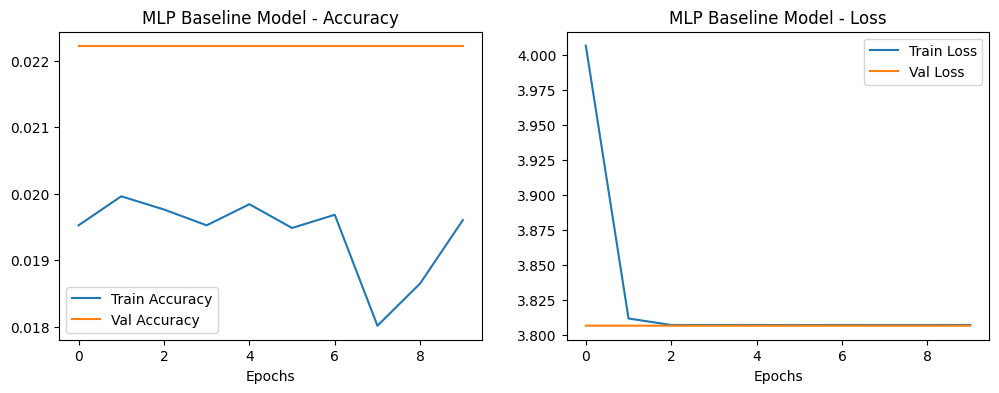

In [ ]:
# Run the function we created earlier
plot_history(mlp_history, "MLP Baseline Model")

In [ ]:

evaluate_model(mlp_model, val_generator, "MLP Model")

NameError: name 'evaluate_model' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def evaluate_model(model, generator, model_name):
    print(f"\n===== {model_name} Evaluation =====")

    # 1. Calculate Accuracy
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"Accuracy: {acc*100:.2f}%")

    # 2. Get Predictions
    y_pred = model.predict(generator)
    y_pred = np.argmax(y_pred, axis=1)
    y_true = generator.classes

    labels = list(generator.class_indices.keys())

    # 3. Create Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10)) # Made larger for your 45 classes
    sns.heatmap(cm, annot=False, cmap='Blues') # Set annot=False because 45x45 is too crowded for numbers
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 4. Detailed Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))


===== MLP Model Evaluation =====
Accuracy: 2.22%
197/197 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step


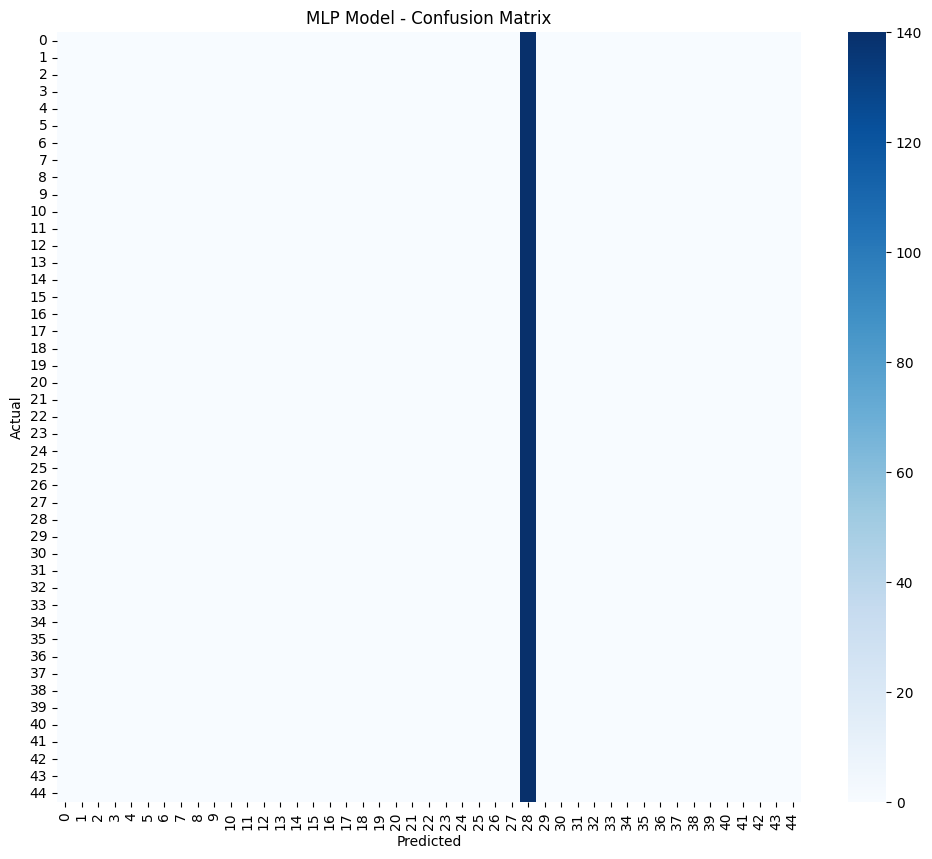


Classification Report:
                       precision    recall  f1-score   support

             airplane       0.00      0.00      0.00       140
              airport       0.00      0.00      0.00       140
     baseball_diamond       0.00      0.00      0.00       140
     basketball_court       0.00      0.00      0.00       140
                beach       0.00      0.00      0.00       140
               bridge       0.00      0.00      0.00       140
            chaparral       0.00      0.00      0.00       140
               church       0.00      0.00      0.00       140
    circular_farmland       0.00      0.00      0.00       140
                cloud       0.00      0.00      0.00       140
      commercial_area       0.00      0.00      0.00       140
    dense_residential       0.00      0.00      0.00       140
               desert       0.00      0.00      0.00       140
               forest       0.00      0.00      0.00       140
              freeway       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
evaluate_model(mlp_model, val_generator, "MLP Model")

In [ ]:
# 1. Define the CNN Model
cnn_model = Sequential([
    # First Layer: Looks for simple edges
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    # Second Layer: Looks for shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Third Layer: Looks for complex patterns
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Prevents memorizing
    Dense(train_generator.num_classes, activation='softmax')
])

# 2. Compile
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Train (This will take a bit longer, but accuracy will jump!)
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 163s 199ms/step - accuracy: 0.1452 - loss: 3.1730 - val_accuracy: 0.3017 - val_loss: 2.5111
Epoch 2/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 162s 206ms/step - accuracy: 0.2726 - loss: 2.5867 - val_accuracy: 0.3660 - val_loss: 2.2154
Epoch 3/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 150s 190ms/step - accuracy: 0.3410 - loss: 2.3177 - val_accuracy: 0.4284 - val_loss: 2.0552
Epoch 4/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 148s 188ms/step - accuracy: 0.3832 - loss: 2.1460 - val_accuracy: 0.4824 - val_loss: 1.7820
Epoch 5/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 150s 190ms/step - accuracy: 0.4181 - loss: 2.0204 - val_accuracy: 0.4660 - val_loss: 1.8764
Epoch 6/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - accuracy: 0.4463 - loss: 1.9237 - val_accuracy: 0.5452 - val_loss: 1.6081
Epoch 7/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 148s 188ms/step - accuracy: 0.4623 - loss: 1.8459 - val_accuracy: 0.5541 - val_loss: 1.5276
Epoch 8/20
788/788 ━━━━━━━━━━━━━━━━━━━━ 149s 189ms/step - accuracy: 0.4846 -

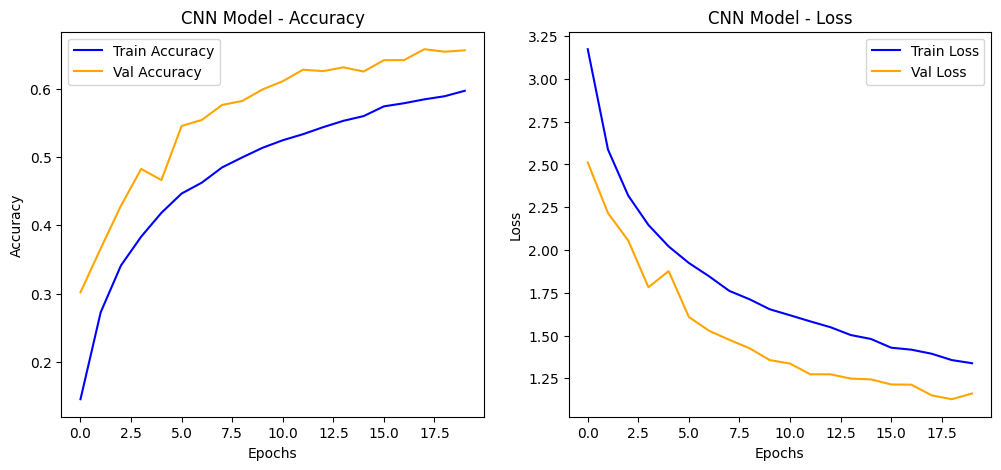

In [ ]:
import matplotlib.pyplot as plt

# Using the cnn_history from your 20-epoch training
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('CNN Model - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Train Loss', color='blue')
plt.plot(cnn_history.history['val_loss'], label='Val Loss', color='orange')
plt.title('CNN Model - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Make sure you have run the 'evaluate_model' function code I gave you earlier
# If you didn't, run that function definition first!

evaluate_model(cnn_model, val_generator, "CNN Model")


===== CNN Model Evaluation =====


In [ ]:
import zipfile
import os

# Unzip the file you just uploaded
zip_ref = zipfile.ZipFile('archive (2).zip', 'r')
zip_ref.extractall('project_data')
zip_ref.close()

print("Unzipping finished! You now have a 'project_data' folder.")

Unzipping finished! You now have a 'project_data' folder.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Point to the folder we just created
base_dir = 'project_data'

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 25200 images belonging to 1 classes.
Found 6300 images belonging to 1 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NEW PATH: This goes deeper into the folder structure shown in your screenshot
base_dir = 'project_data/ISatelitales'

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training Generator
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation Generator
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 25200 images belonging to 45 classes.
Found 6300 images belonging to 45 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load the pre-trained 'brain' (Base Model)
# We use weights='imagenet' to start with a smart model, not a blank one.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

# 2. Build the Model Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# 3. Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Train (This will be much faster and more accurate than your previous CNN)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load the pre-trained 'brain' (Base Model)
# We use weights='imagenet' to start with a smart model, not a blank one.
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

# 2. Build the Model Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# 3. Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Train (This will be much faster and more accurate than your previous CNN)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 86s 84ms/step - accuracy: 0.5604 - loss: 1.5696 - val_accuracy: 0.7505 - val_loss: 0.8427
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.7010 - loss: 0.9966 - val_accuracy: 0.7746 - val_loss: 0.7296
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.7432 - loss: 0.8506 - val_accuracy: 0.7810 - val_loss: 0.7114
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.7621 - loss: 0.7748 - val_accuracy: 0.7952 - val_loss: 0.6737
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7794 - loss: 0.7118 - val_accuracy: 0.7922 - val_loss: 0.6781
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.7892 - loss: 0.6683 - val_accuracy: 0.7951 - val_loss: 0.6841
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.8050 - loss: 0.6119 - val_accuracy: 0.8029 - val_loss: 0.6627
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3

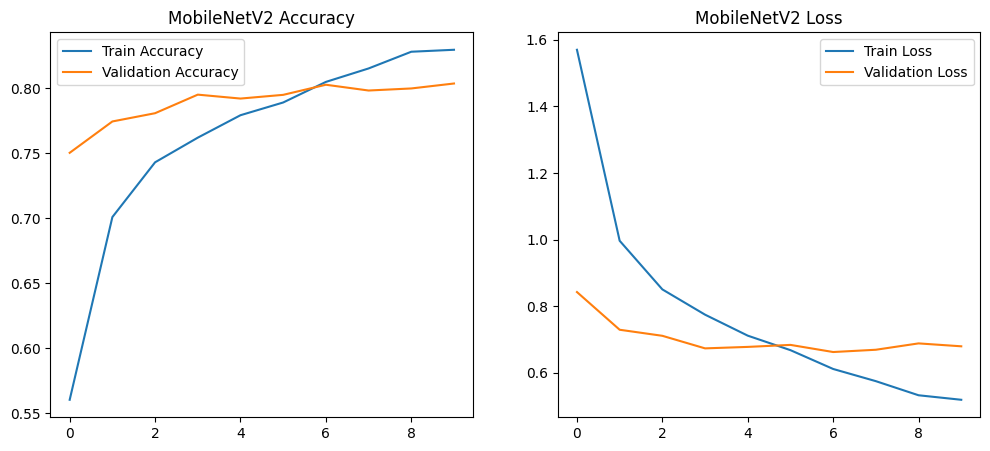

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.legend()
plt.show()

197/197 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step


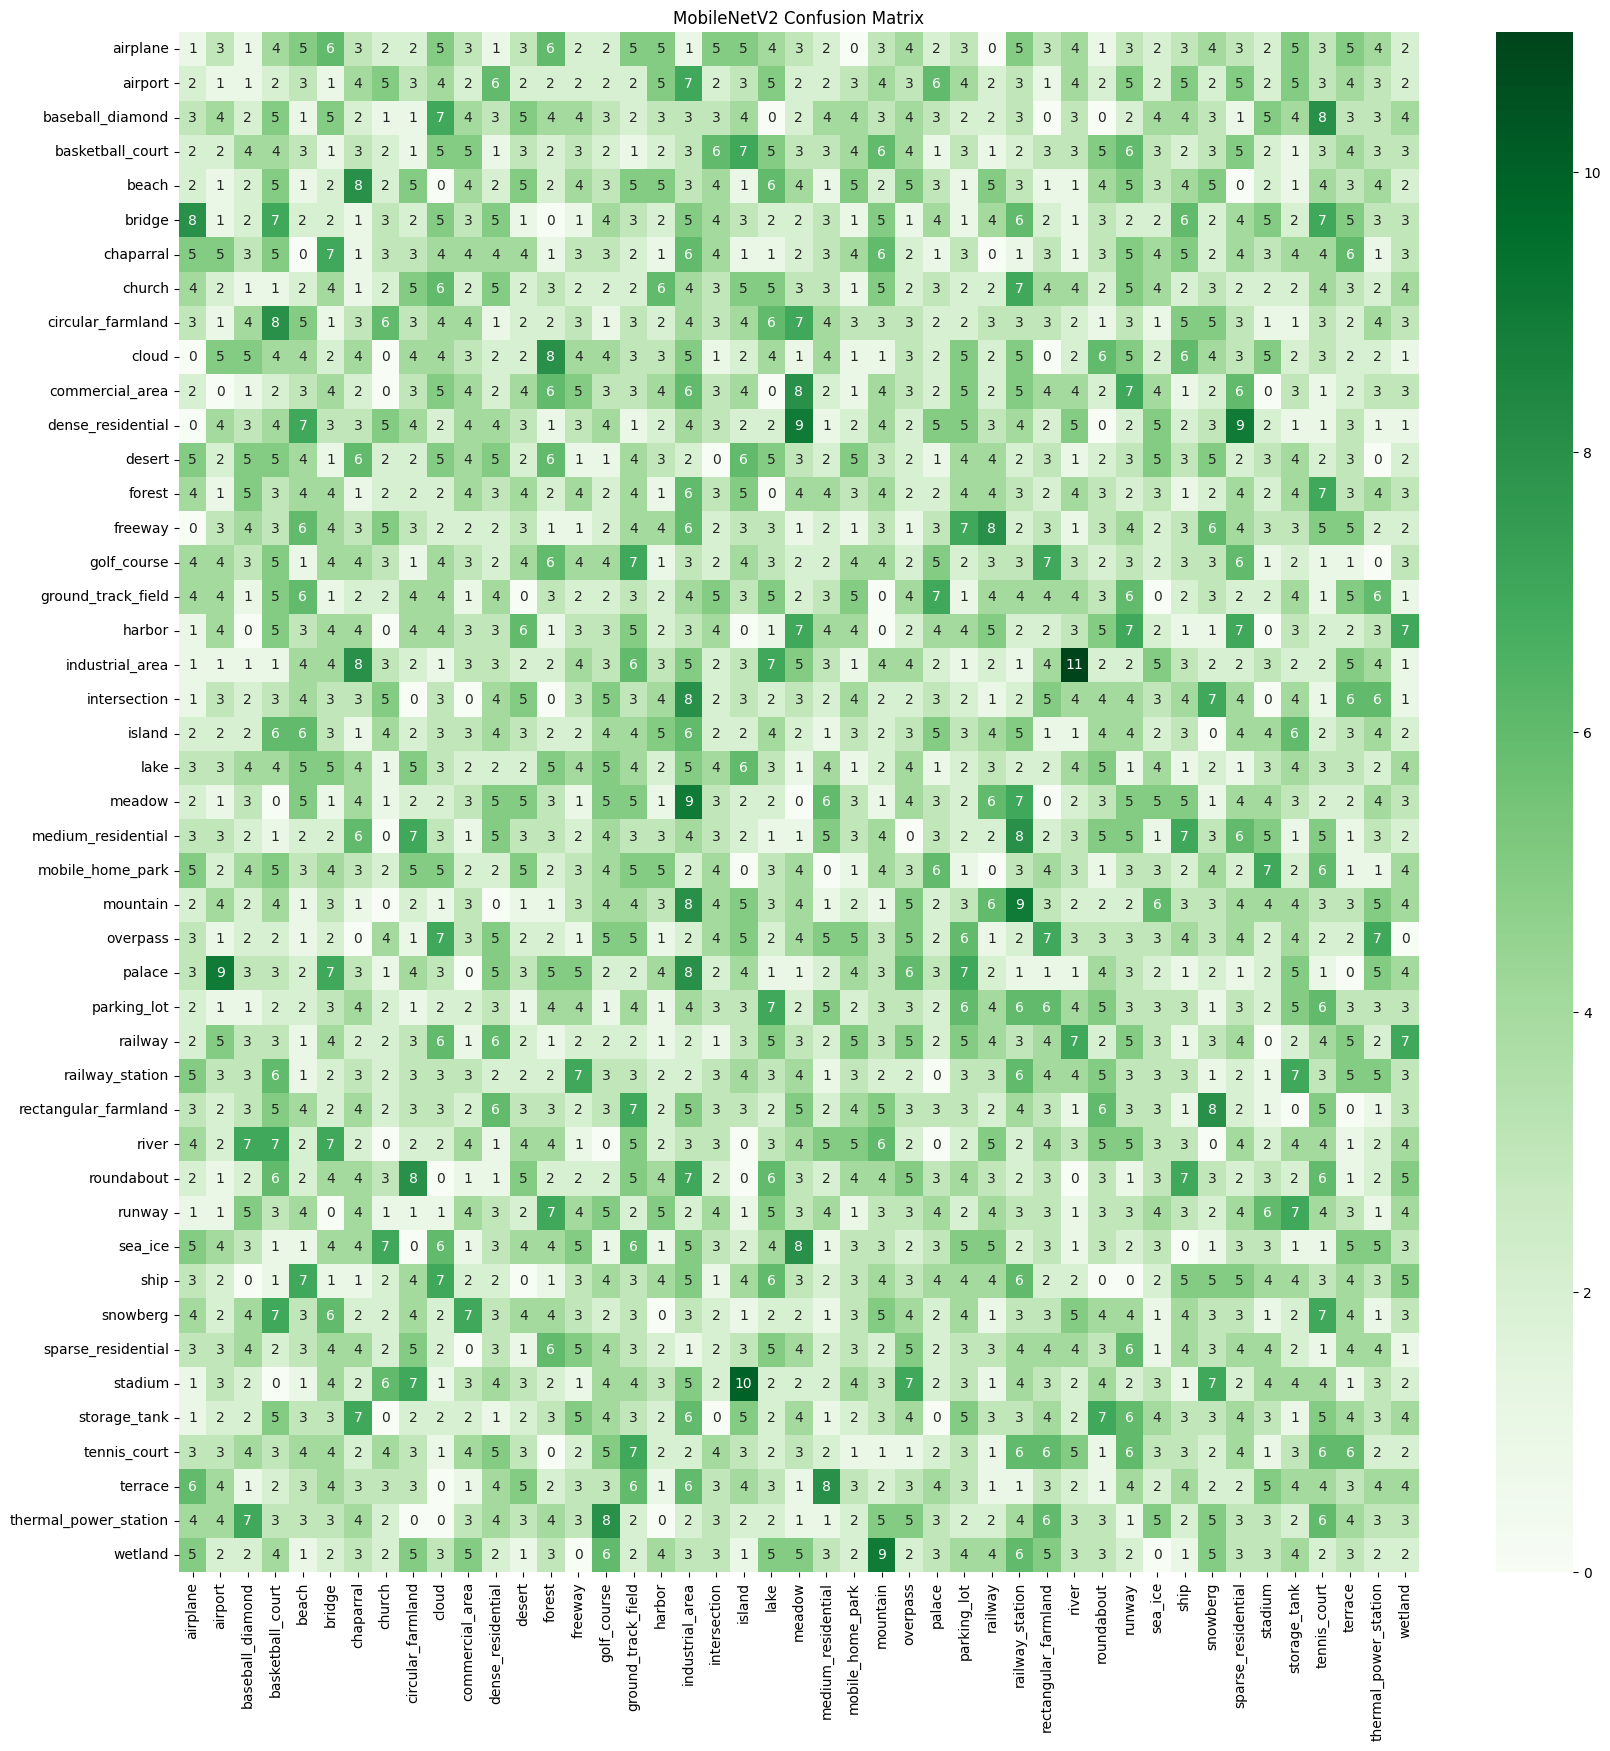

                       precision    recall  f1-score   support

             airplane       0.01      0.01      0.01       140
              airport       0.01      0.01      0.01       140
     baseball_diamond       0.02      0.01      0.02       140
     basketball_court       0.02      0.03      0.03       140
                beach       0.01      0.01      0.01       140
               bridge       0.01      0.01      0.01       140
            chaparral       0.01      0.01      0.01       140
               church       0.02      0.01      0.02       140
    circular_farmland       0.02      0.02      0.02       140
                cloud       0.03      0.03      0.03       140
      commercial_area       0.03      0.03      0.03       140
    dense_residential       0.03      0.03      0.03       140
               desert       0.02      0.01      0.01       140
               forest       0.02      0.01      0.01       140
              freeway       0.01      0.01      0.01  

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Create Heatmap
plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

# Print the text report for your project file
print(classification_report(y_true, y_pred, target_names=class_labels))

In [ ]:
model.save("satellite_mobilenet_80.h5")

import json
with open('mobilenet_labels.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 1. Load ResNet50 (A powerful model with skip-connections)
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_resnet.trainable = False

# 2. Add the custom layers for your 45 classes
resnet_model = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# 3. Compile
resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Train
print("Starting ResNet50 Training...")
resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Starting ResNet50 Training...
Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 65s 67ms/step - accuracy: 0.0429 - loss: 3.6773 - val_accuracy: 0.0794 - val_loss: 3.5296
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.0657 - loss: 3.5047 - val_accuracy: 0.0946 - val_loss: 3.4125
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.0857 - loss: 3.4296 - val_accuracy: 0.1203 - val_loss: 3.3407
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.0994 - loss: 3.3720 - val_accuracy: 0.1351 - val_loss: 3.2886
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.1090 - loss: 3.3264 - val_accuracy: 0.1513 - val_loss: 3.2266
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.1188 - loss: 3.2908 - val_accuracy: 0.1573 - val_loss: 3.1951
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.1294 - loss: 3.2557 - val_accuracy: 0.1692 - val_loss: 3.1438
Epoch 8/1

In [ ]:
# 1. Load ResNet50 again
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# 2. UNFREEZE the base so it can actually learn (This is the change!)
base_resnet.trainable = True

# 3. Build with better layers
resnet_model = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# 4. Use a slower learning rate (important when unfreezing)
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train again
resnet_history = resnet_model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 199s 178ms/step - accuracy: 0.6752 - loss: 1.2371 - val_accuracy: 0.2338 - val_loss: 3.7034
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 111s 140ms/step - accuracy: 0.8693 - loss: 0.4509 - val_accuracy: 0.8790 - val_loss: 0.4277
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 109s 138ms/step - accuracy: 0.9152 - loss: 0.2860 - val_accuracy: 0.8986 - val_loss: 0.4094
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.9359 - loss: 0.2195 - val_accuracy: 0.8867 - val_loss: 0.4258
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 112s 142ms/step - accuracy: 0.9501 - loss: 0.1671 - val_accuracy: 0.8951 - val_loss: 0.4349
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 109s 138ms/step - accuracy: 0.9540 - loss: 0.1545 - val_accuracy: 0.8852 - val_loss: 0.4411
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 110s 139ms/step - accuracy: 0.9624 - loss: 0.1248 - val_accuracy: 0.9019 - val_loss: 0.4325
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 110s 139ms/step - accuracy: 0.9633 -

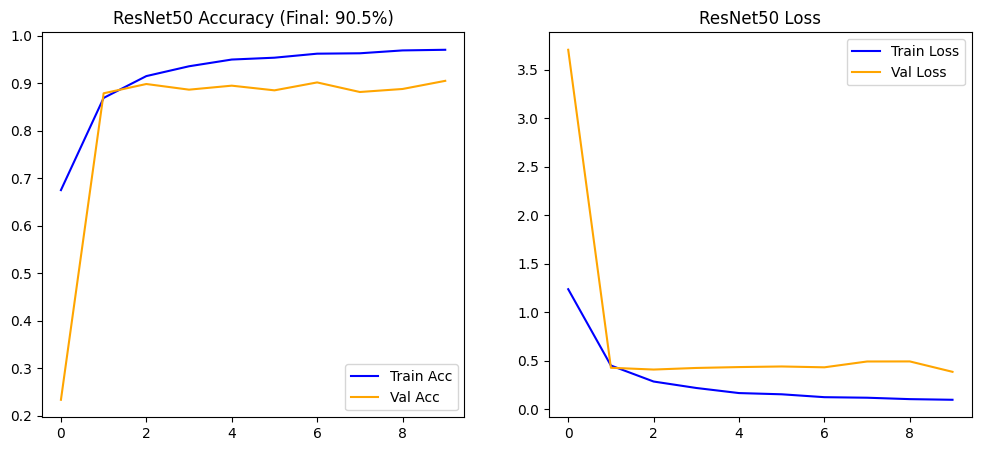

197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step


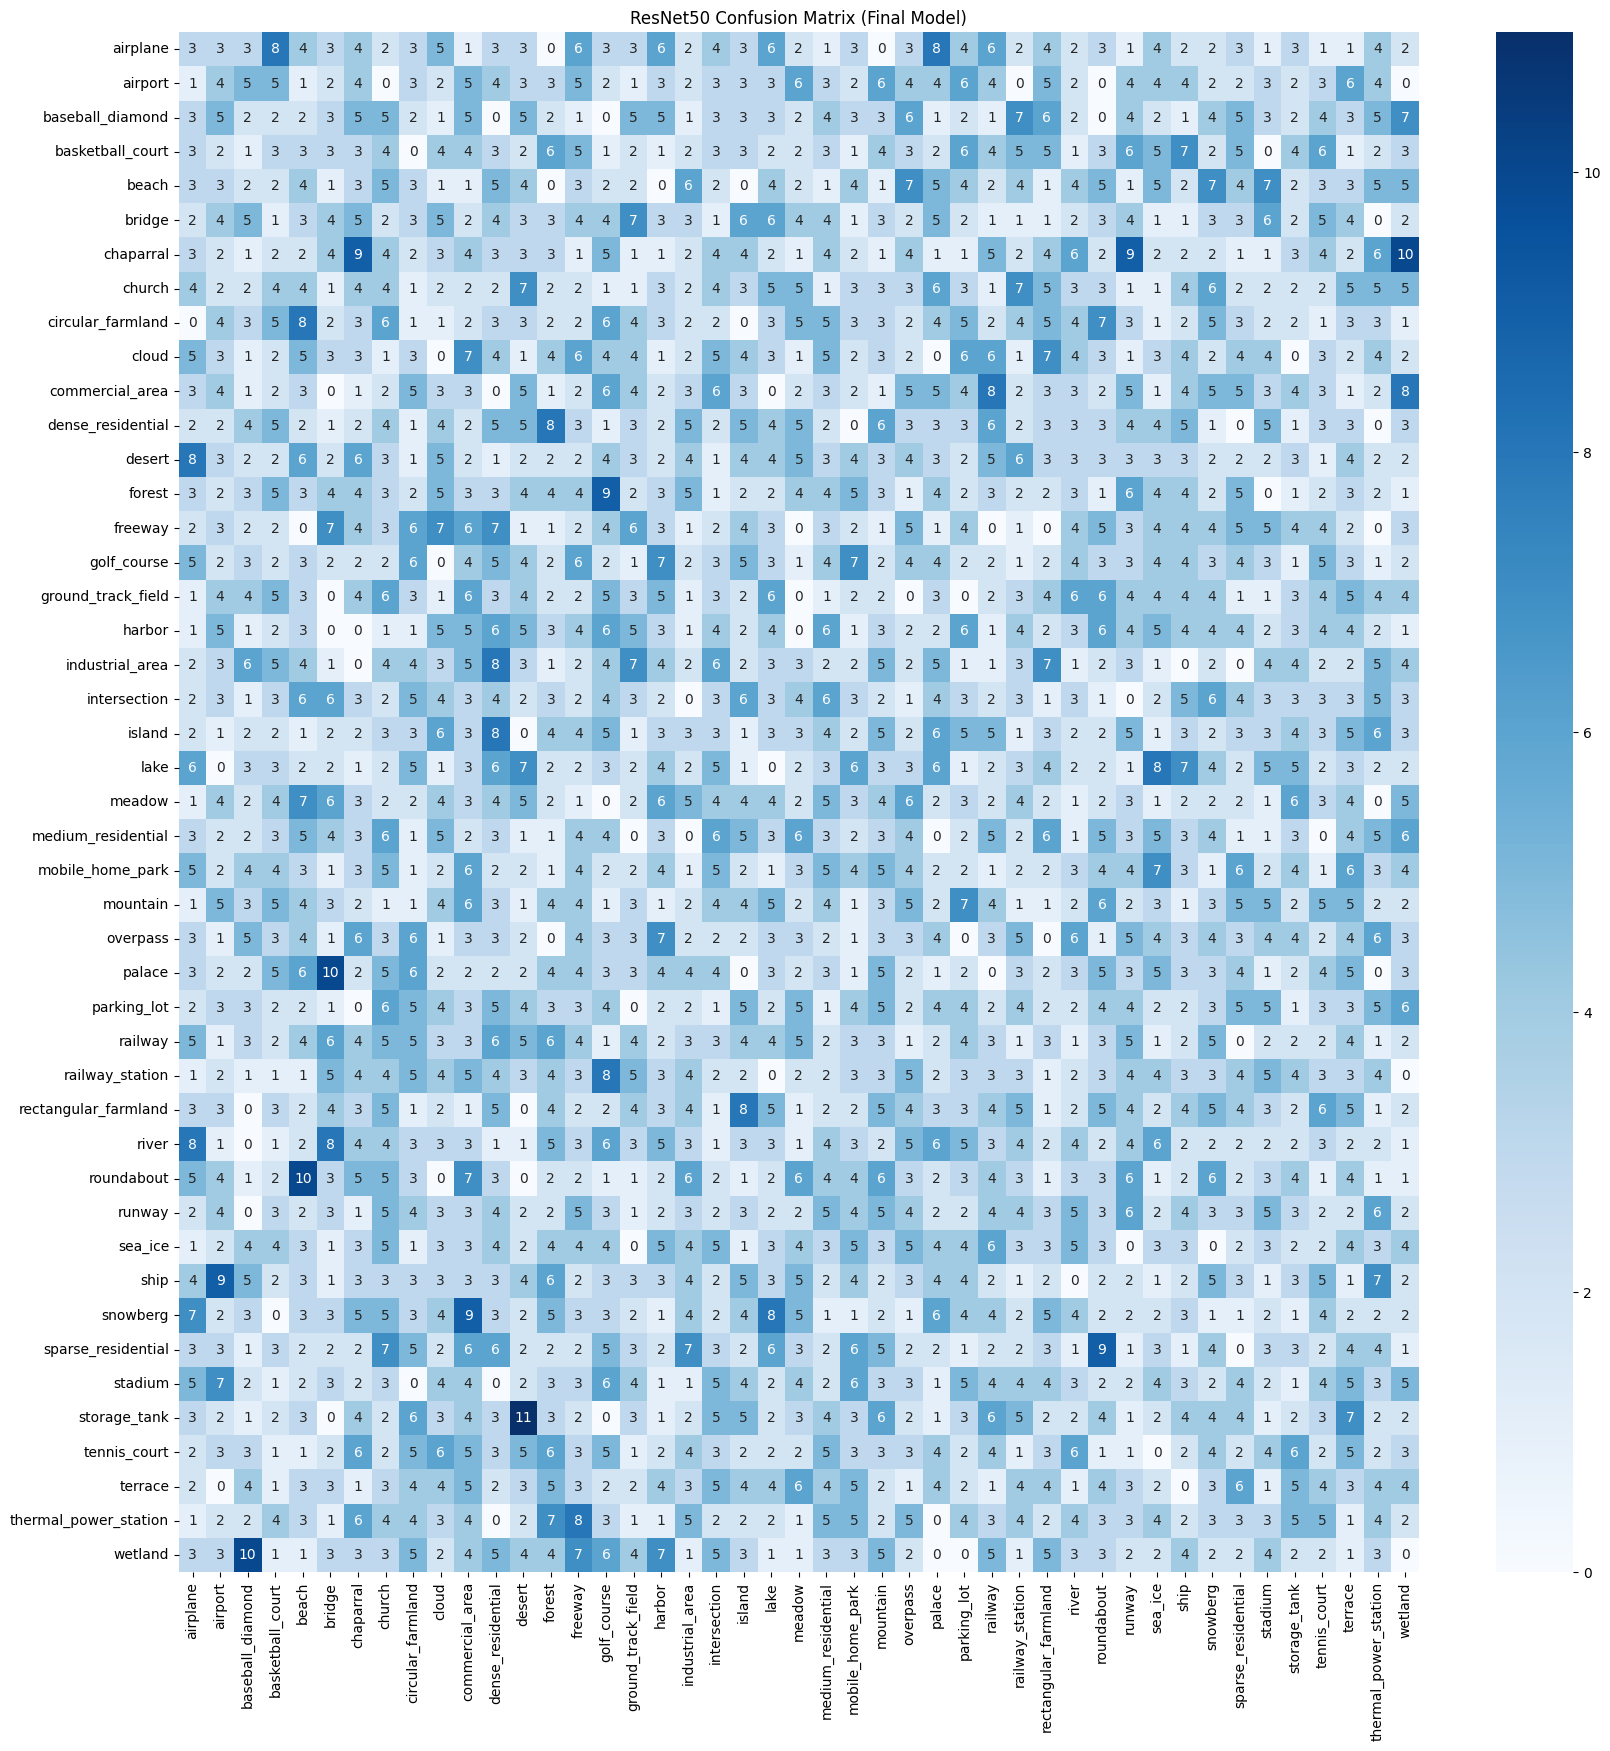

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- 1. ACCURACY & LOSS GRAPHS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(resnet_history.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('ResNet50 Accuracy (Final: 90.5%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'], label='Train Loss', color='blue')
plt.plot(resnet_history.history['val_loss'], label='Val Loss', color='orange')
plt.title('ResNet50 Loss')
plt.legend()
plt.show()

# --- 2. CONFUSION MATRIX ---
# This takes a minute to run
Y_pred = resnet_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(20, 20))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('ResNet50 Confusion Matrix (Final Model)')
plt.show()

In [ ]:
resnet_model.save("satellite_resnet_final_90.h5")

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# 1. Load VGG16 base - Unfrozen for maximum accuracy
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_vgg.trainable = True

# 2. Build the Model Architecture
vgg_model = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# 3. Compile with a stable learning rate for transfer learning
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the final model
print("Starting VGG16 Training...")
vgg_history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# 5. Save the model immediately after training finishes
vgg_model.save("satellite_vgg16_final.h5")
print("VGG16 Model saved as satellite_vgg16_final.h5")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Starting VGG16 Training...
Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 221s 238ms/step - accuracy: 0.0198 - loss: 3.8102 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 157s 199ms/step - accuracy: 0.0217 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 157s 199ms/step - accuracy: 0.0213 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 164s 209ms/step - accuracy: 0.0200 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 157s 199ms/step - accuracy: 0.0203 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 202s 200ms/step - accuracy: 0.0216 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.8067
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 164s 209ms/step - accuracy: 0.0204 - loss: 3.8067 - val_accuracy: 0.0222 - val_loss: 3.806

VGG16 Model saved as satellite_vgg16_final.h5


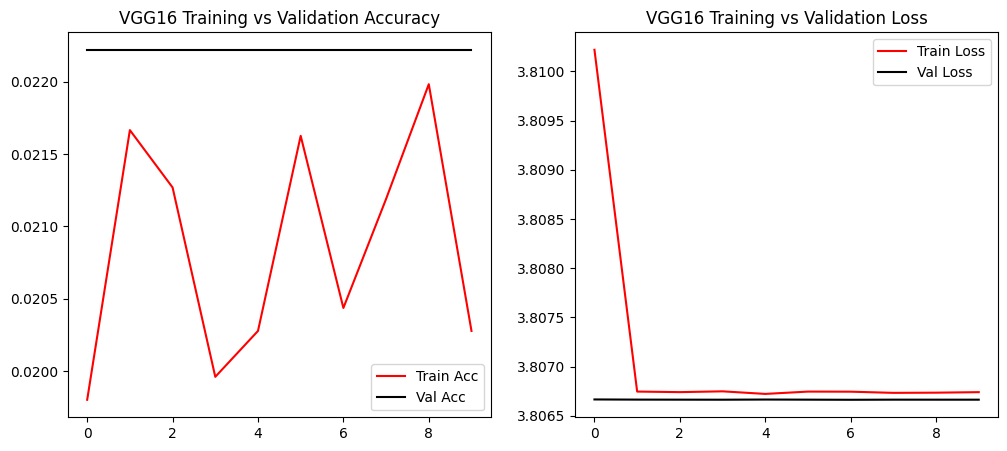

Generating Confusion Matrix... please wait.
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step


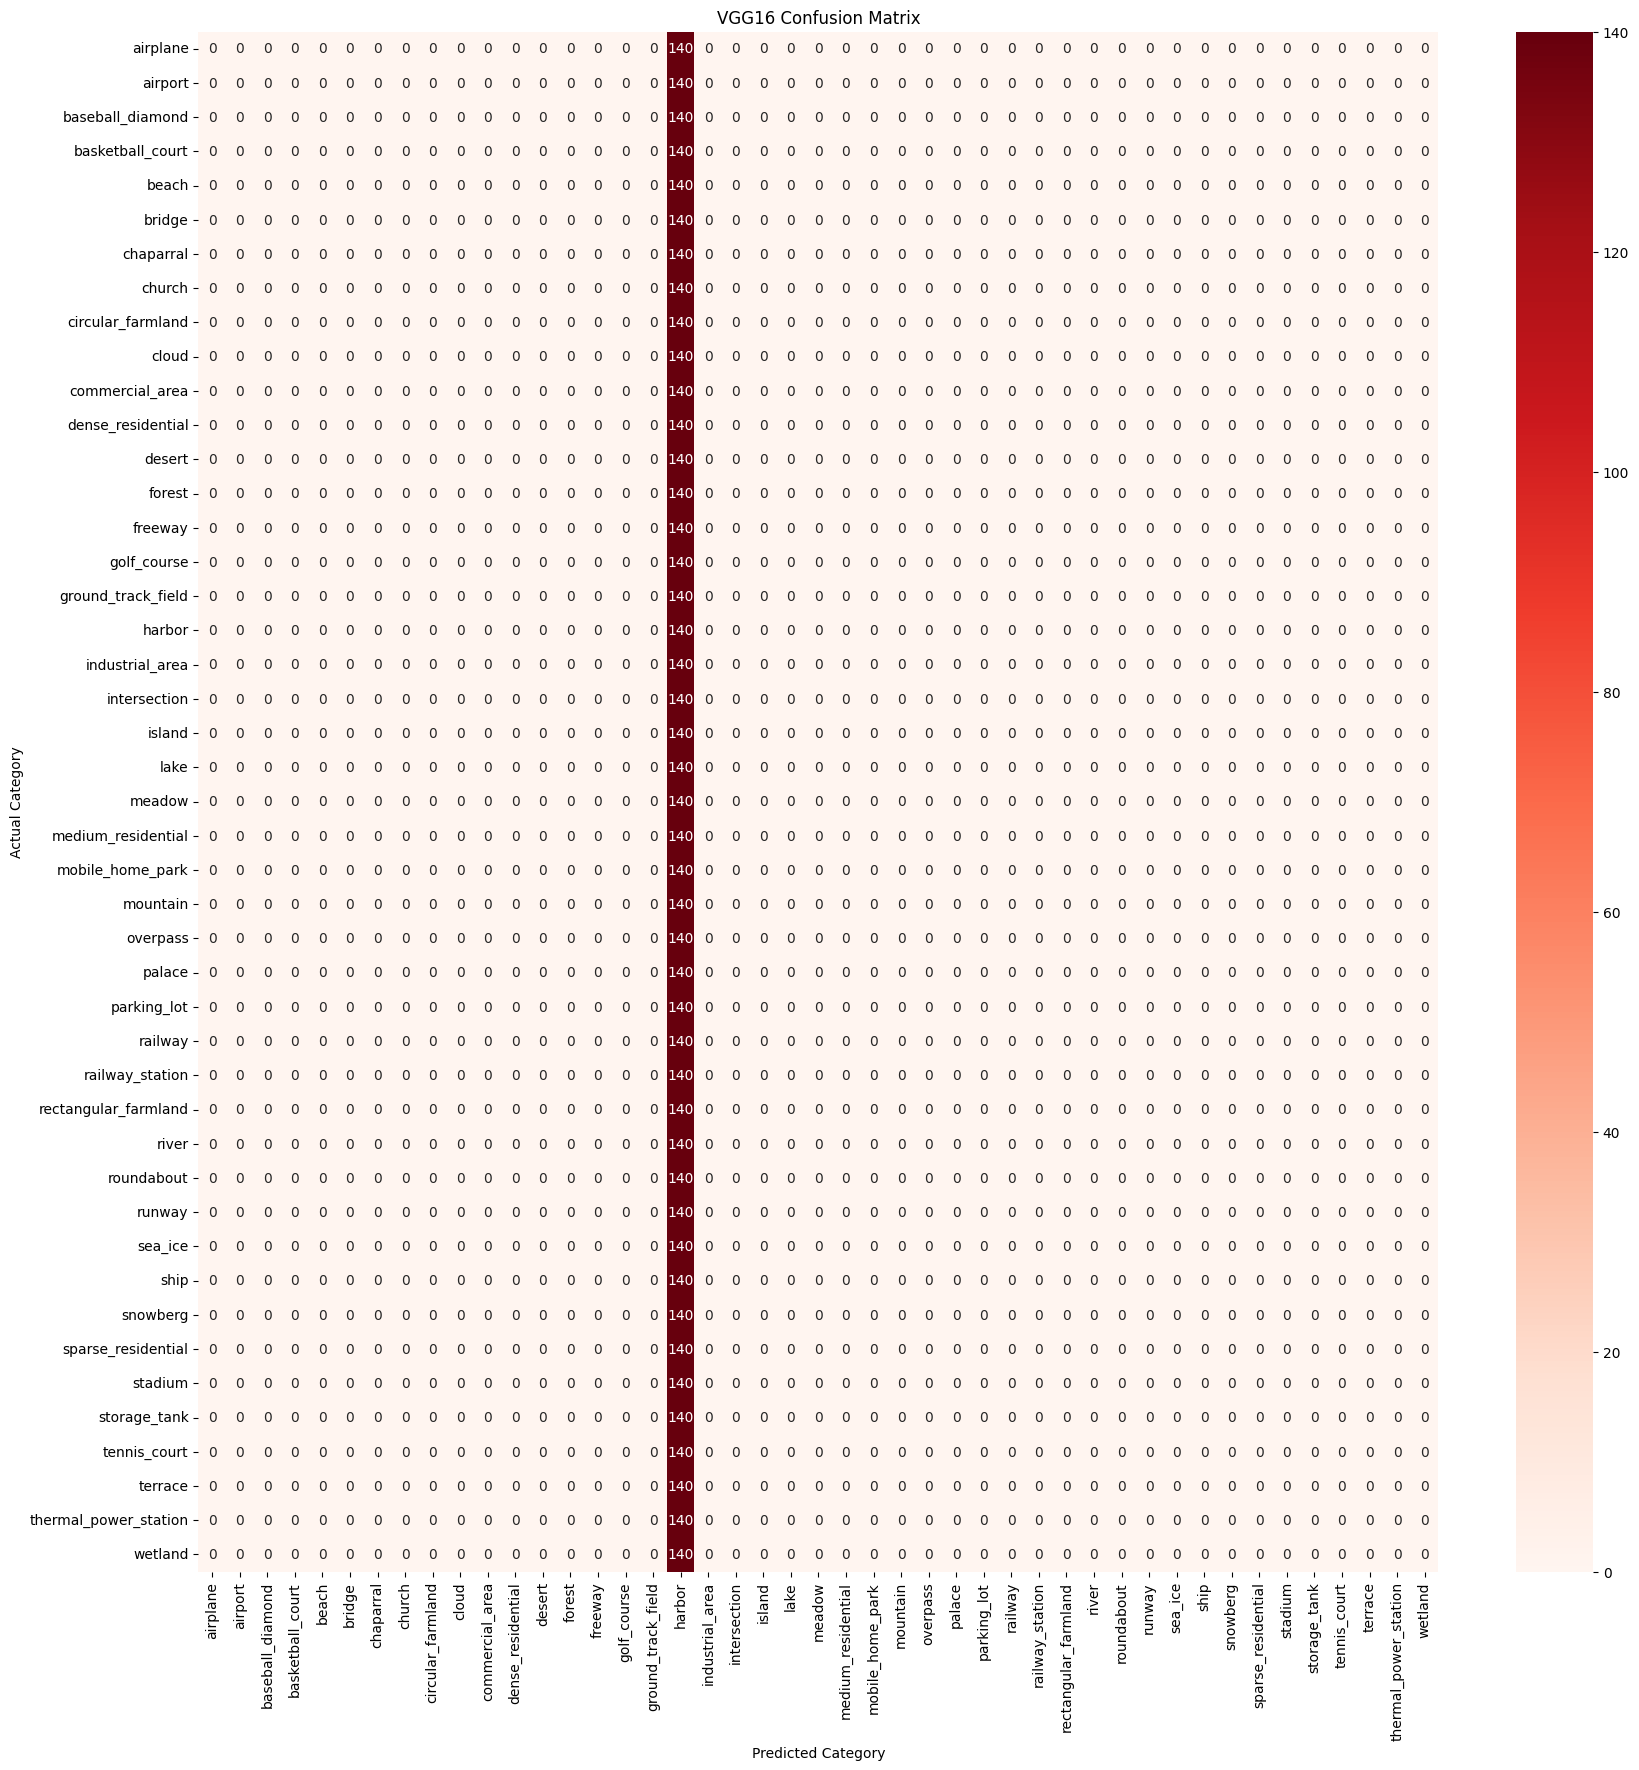


--- VGG16 Classification Report ---
                       precision    recall  f1-score   support

             airplane       0.00      0.00      0.00       140
              airport       0.00      0.00      0.00       140
     baseball_diamond       0.00      0.00      0.00       140
     basketball_court       0.00      0.00      0.00       140
                beach       0.00      0.00      0.00       140
               bridge       0.00      0.00      0.00       140
            chaparral       0.00      0.00      0.00       140
               church       0.00      0.00      0.00       140
    circular_farmland       0.00      0.00      0.00       140
                cloud       0.00      0.00      0.00       140
      commercial_area       0.00      0.00      0.00       140
    dense_residential       0.00      0.00      0.00       140
               desert       0.00      0.00      0.00       140
               forest       0.00      0.00      0.00       140
              fre

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# --- 1. ACCURACY & LOSS GRAPHS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Train Acc', color='red')
plt.plot(vgg_history.history['val_accuracy'], label='Val Acc', color='black')
plt.title('VGG16 Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Train Loss', color='red')
plt.plot(vgg_history.history['val_loss'], label='Val Loss', color='black')
plt.title('VGG16 Training vs Validation Loss')
plt.legend()
plt.show()

# --- 2. CONFUSION MATRIX (Heatmap) ---
print("Generating Confusion Matrix... please wait.")
vgg_pred = vgg_model.predict(val_generator)
y_pred_vgg = np.argmax(vgg_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(20, 20))
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('VGG16 Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# --- 3. TEXT REPORT ---
print("\n--- VGG16 Classification Report ---")
print(classification_report(y_true, y_pred_vgg, target_names=class_labels))

In [1]:
import os
import zipfile
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
zip_filename = "/content/archive (2).zip"

In [4]:
extract_path = "/content/satellite_dataset"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files_list in os.walk(extract_path):
    print(root, "contains", len(files_list), "files")

/content/satellite_dataset contains 0 files
/content/satellite_dataset/ISatelitales contains 0 files
/content/satellite_dataset/ISatelitales/storage_tank contains 700 files
/content/satellite_dataset/ISatelitales/ship contains 700 files
/content/satellite_dataset/ISatelitales/cloud contains 700 files
/content/satellite_dataset/ISatelitales/beach contains 700 files
/content/satellite_dataset/ISatelitales/medium_residential contains 700 files
/content/satellite_dataset/ISatelitales/ground_track_field contains 700 files
/content/satellite_dataset/ISatelitales/tennis_court contains 700 files
/content/satellite_dataset/ISatelitales/roundabout contains 700 files
/content/satellite_dataset/ISatelitales/runway contains 700 files
/content/satellite_dataset/ISatelitales/basketball_court contains 700 files
/content/satellite_dataset/ISatelitales/mobile_home_park contains 700 files
/content/satellite_dataset/ISatelitales/sea_ice contains 700 files
/content/satellite_dataset/ISatelitales/baseball_d

In [6]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    extract_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 25200 images belonging to 1 classes.


In [8]:
extract_path = "/content/satellite_dataset/ISatelitales"

In [9]:
train_generator = train_datagen.flow_from_directory(
    extract_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 25200 images belonging to 45 classes.


In [10]:
val_generator = train_datagen.flow_from_directory(
    extract_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 6300 images belonging to 45 classes.


In [11]:
labels = train_generator.class_indices

with open("/content/mobilenet_labels.json", "w") as f:
    json.dump(labels, f)

print("Labels saved successfully!")

Labels saved successfully!


In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,485 (9.91 MB)

 Trainable params: 339,501 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [17]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 199s 227ms/step - accuracy: 0.5096 - loss: 1.7648 - val_accuracy: 0.7052 - val_loss: 0.9919 - learning_rate: 0.0010
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 149s 189ms/step - accuracy: 0.6410 - loss: 1.2268 - val_accuracy: 0.7319 - val_loss: 0.9113 - learning_rate: 0.0010
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 148s 187ms/step - accuracy: 0.6699 - loss: 1.1199 - val_accuracy: 0.7441 - val_loss: 0.8517 - learning_rate: 0.0010
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 150s 190ms/step - accuracy: 0.6842 - loss: 1.0609 - val_accuracy: 0.7416 - val_loss: 0.8426 - learning_rate: 0.0010
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 152s 192ms/step - accuracy: 0.6912 - loss: 1.0314 - val_accuracy: 0.7606 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 152s 192ms/step - accuracy: 0.6978 - loss: 1.0073 - val_accuracy: 0.7562 - val_loss: 0.7937 - learning_rate: 0.0010
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 150s 191ms/step - accura

In [18]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 187s 215ms/step - accuracy: 0.6758 - loss: 1.1548 - val_accuracy: 0.7454 - val_loss: 0.8643 - learning_rate: 1.0000e-04
Epoch 2/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 153s 194ms/step - accuracy: 0.7428 - loss: 0.8498 - val_accuracy: 0.7625 - val_loss: 0.7946 - learning_rate: 1.0000e-04
Epoch 3/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 153s 194ms/step - accuracy: 0.7825 - loss: 0.7103 - val_accuracy: 0.8167 - val_loss: 0.6116 - learning_rate: 2.0000e-05
Epoch 4/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 165s 209ms/step - accuracy: 0.7936 - loss: 0.6701 - val_accuracy: 0.8243 - val_loss: 0.5787 - learning_rate: 2.0000e-05
Epoch 5/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 164s 208ms/step - accuracy: 0.7988 - loss: 0.6389 - val_accuracy: 0.8286 - val_loss: 0.5611 - learning_rate: 2.0000e-05


In [21]:
model.save("/content/fixed_satellite_model.keras")

In [22]:
files.download("/content/fixed_satellite_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
files.download("/content/mobilenet_labels.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>